In [1]:
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
from utils import get_data
from scipy.signal import savgol_filter
from scipy.stats import linregress

Text(0.5, 0, 'MHz')

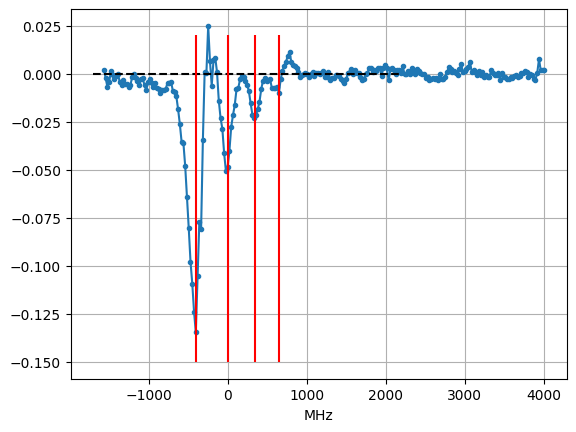

In [2]:
data = np.loadtxt("test_data.csv", skiprows=1, delimiter=",")
x, y = data[:, 0], data[:, 1]
#x_bg0= np.concatenate([x[0:30], x[-25:-1]])
#y_bg0= np.concatenate([y[0:30], y[-25:-1]])
bg = np.loadtxt("background.csv", skiprows=1, delimiter=",")
x_bg, y_bg = bg[:, 0][100:350], bg[:, 1][100:350]
a, b, _,_,_= linregress(x_bg,y_bg)


y_f = np.flip(y - (a*x + b))
x_f = np.flip((x-72.8) * -22.4/0.01)
#y_s = savgol_filter(y, window_length=5, polyorder=3)

plt.plot(x_f, y_f, ".-")
plt.hlines(0, xmin=-1700, xmax=2200, color="black", linestyles="--")
plt.vlines([-400, 0, 350, 650], -0.15, 0.02, color="red")
plt.grid()
plt.xlabel("MHz")